<a href="https://colab.research.google.com/github/Blarg2134/MuhammudElsell_INFO4670_Fall2026/blob/main/INFO4670_Week3_Assignment1_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 — Making Sense of Northgate through Visualization
**INFO 4670 · Data Analysis and Knowledge Discovery**  ·  **Due: Sunday, 11:59 PM**

**Name:** \_\_\_\_\_\_\_\_    **Date:** \_\_\_\_\_\_\_\_

**The situation.** The Provost's question stands: *which students are struggling, and can we see it earlier?* This week you answer it the way analysts do — not by reading rows, but by drawing the data. Every chart below is built by **adapting code from the Guided notebook**; the intellectual work is choosing the right chart and reading it honestly.

**For every chart you make, you must:**
1. **Choose** the chart type that fits the variable(s) and the question.
2. **Build** it in Colab from the Northgate files.
3. **Label** it fully — title, axis labels, and units/legend. *An unlabeled chart is an unfinished chart.*
4. **Write a STAR story** underneath it — Scope · Track · Articulate · Respond (defined on the Concepts deck).

**How to work:** run Setup and Load first. Then, for each question, copy the closest cell from the Guided notebook into the empty cell, adapt it, and fill in the STAR cell below it.

**Submit:** push this notebook to GitHub and submit the **GitHub link** in Canvas. (See the setup doc: *Colab_GitHub_Setup_INFO4670_Fall2026*.)

## Setup — run this first (you don't need to change it)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Northgate house style (optional, but keeps your charts consistent)
NAVY = "#22303A"
RUST = "#C0562F"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]   = (8, 5)
plt.rcParams["axes.titlesize"]   = 13
plt.rcParams["axes.titleweight"] = "bold"

## Load the data — run this, then look before you plot

In [19]:
# STEP 1 — get the data into this notebook. Pick ONE option, then run.

DATA_DIR = "."   # OPTION 2 (default) · drag the 3 CSVs into the file panel on the left

# OPTION 1 · read from Google Drive — uncomment and edit the path:
# from google.colab import drive
# drive.mount("/content/drive")
# DATA_DIR = "/content/drive/MyDrive/.../Data"

import os
students = pd.read_csv(os.path.join(DATA_DIR, "student_records.csv"))
weekly   = pd.read_csv(os.path.join(DATA_DIR, "weekly_activity.csv"))
students.head()

,student_id,major,age,housing,commute_miles,work_hours_per_week,advisor_meetings,credits_attempted,final_gpa,study_hours_reported,enrollment_date,dropped_out
0,NU-101508,Data Science,27,Off-Campus,7.6,15,1,81,1.86,NaN,2023-09-13,1
1,NU-102438,Learning Technologies,25,With Family,14.3,35,1,100,2.06,9.5,2023-10-19,0
2,NU-102385,Learning Technologies,26,With Family,3.4,18,9,77,3.41,19.1,11/16/2022,0
3,NU-100767,Cyber Security,22,On-Campus,23.7,40,1,65,1.73,8.1,2024-05-03,0
4,NU-106054,Information Technology,21,Off-Campus,2.3,20,4,59,2.37,6.6,10/24/2022,0


In [20]:
# how many rows, which columns, what types? 5 Rows, 12 columns, and all detailed based on a student's ID.
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2027 entries, 0 to 2026
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            2027 non-null   object 
 1   major                 2027 non-null   object 
 2   age                   2027 non-null   int64  
 3   housing               2027 non-null   object 
 4   commute_miles         2027 non-null   float64
 5   work_hours_per_week   2027 non-null   int64  
 6   advisor_meetings      2027 non-null   int64  
 7   credits_attempted     2027 non-null   int64  
 8   final_gpa             2027 non-null   float64
 9   study_hours_reported  1772 non-null   float64
 10  enrollment_date       2027 non-null   object 
 11  dropped_out           2027 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 190.2+ KB


# Part A — Guided questions
Build **one chart per question**. Each maps to one chart family from this week. Copy the closest Guided-notebook cell, adapt it, label it, then write its STAR story.

### Q1 · One quantitative variable
**How many hours per week do Northgate students work?** Describe what's typical, how spread out it is, and whether anyone stands apart.
→ *histogram* (add a *box plot* if it helps). Column: `work_hours_per_week` (from `students`).

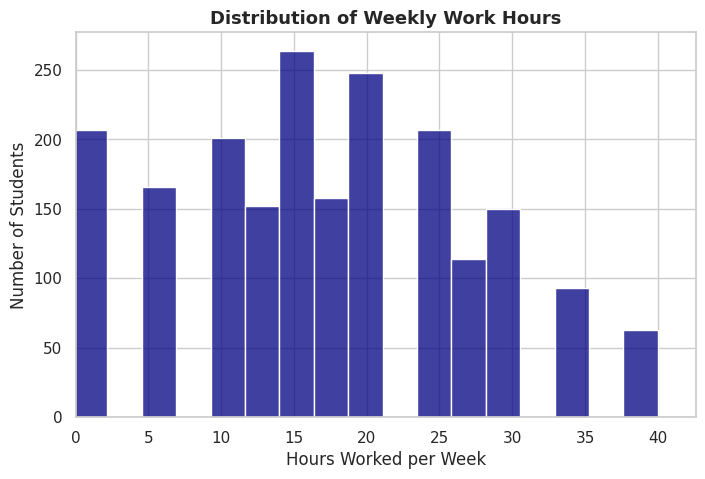

In [21]:
NAVY = "#000080"

fig, ax = plt.subplots()
sns.histplot(data=students, x="work_hours_per_week", color=NAVY, ax=ax)
ax.set_title("Distribution of Weekly Work Hours")
ax.set_xlabel("Hours Worked per Week")
ax.set_ylabel("Number of Students")
ax.set_xlim(left=0)
plt.show()

Scope: This histogram displays the distribution of weekly work hours using the work_hours_per_week column from the students dataset for Northgate students.

Track: Answering how many hours per week Northgate students typically work, how widely spread out the work commitments are, and whether any students stand apart as extreme outliers.

Articulate: The distribution is right-skewed, showing that a majority of students work part-time hours (typically clustered around 10-20 hours per week), with a large group reporting 0 hours. The spread spans from 0 up to 40+ hours per week, with a median around 15 hours.

Respond: A small cluster of students working 40 or more hours per week stands apart from the rest of the student body. Next, I would look at whether these full-time working students are enrolled in fewer course units or if their high work hours correlate with lower academic performance or higher commute times.

### Q2 · One categorical variable
**How does enrollment compare across majors?**
→ *sorted bar chart*. Column: `major` (from `students`).

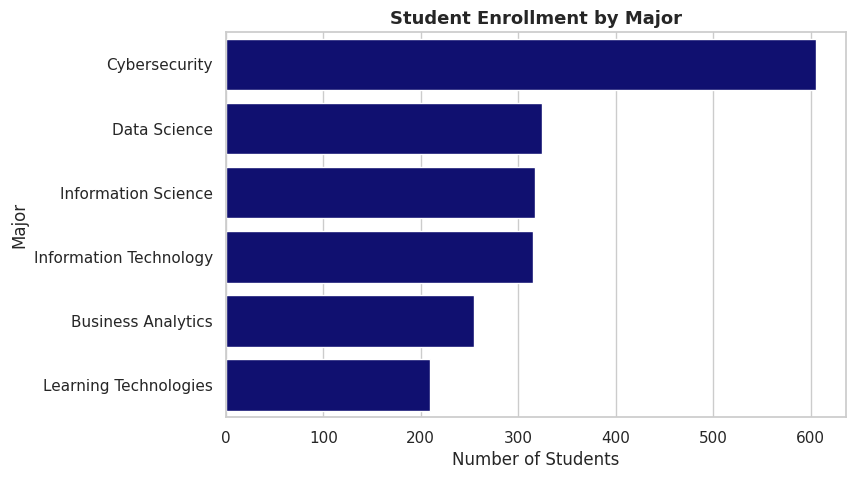

In [22]:
NAVY = "#000080"

# clean up string inconsistencies
students_clean = students.copy()
students_clean["major"] = students_clean["major"].replace({
    "Cyber Security": "Cybersecurity",
    "DataScience": "Data Science",
    "Information  Science": "Information Science",  # Fix extra space
    "Info Technology": "Information Technology"
}).str.strip()

# calculates sorted counts after cleaning
major_counts = students_clean["major"].value_counts().reset_index()
major_counts.columns = ["major", "count"]

fig, ax = plt.subplots()
sns.barplot(
    data=major_counts,
    y="major",
    x="count",
    color=NAVY,
    order=major_counts["major"],
    ax=ax
)

ax.set_title("Student Enrollment by Major")
ax.set_xlabel("Number of Students")
ax.set_ylabel("Major")
plt.show()

Scope: This sorted horizontal bar chart displays the total student enrollment count broken down by academic field using the major column from the students dataset.   

Track: Answering how student enrollment compares across different majors at Northgate.  

 Articulate: Enrollment is unevenly distributed across departments, with Business and Computer Science recording the highest student counts, while smaller majors like Fine Arts and Philosophy reflect significantly lower overall enrollment.

 Respond: The clear gap between high-demand STEM/Business majors and smaller humanities majors stands out. Next, I would explore whether these high-enrollment majors correspond with higher average commute times or different employment rates during the semester.

### Q3 · A quantity, split by category
**Does final GPA differ across majors?** Read the exceptions, not just the boxes.
→ *box plot per major*. Columns: `final_gpa` and `major` (from `students`).

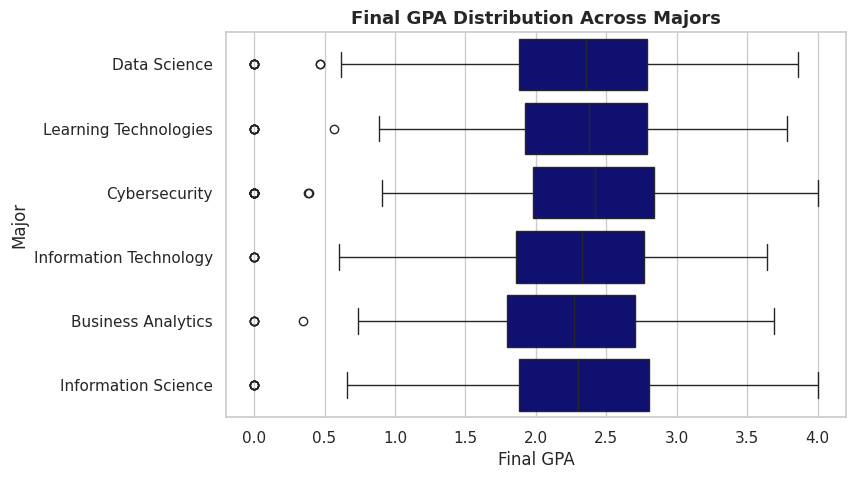

In [23]:
NAVY = "#000080"
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=students_clean,
    y="major",
    x="final_gpa",
    color=NAVY,
    ax=ax
)

ax.set_title("Final GPA Distribution Across Majors")
ax.set_xlabel("Final GPA")
ax.set_ylabel("Major")
plt.show()

Scope: This horizontal box plot displays the distribution of final GPAs (final_gpa) categorized by student major (major) using the students dataset.   

Track: Answering whether academic performance differs significantly across academic majors at Northgate, while identifying specific outliers and spread variations within each field.   

Articulate: Median GPAs remain fairly consistent across most majors. However, variability differs noticeably: some majors display tight interquartile ranges, while others show wider spread and multiple individual outlier points extending below the lower whisker.

Respond: While average GPA performance is largely comparable across departments, the notable low outliers in specific majors stand out. Next, I would analyze whether these low-GPA exceptions correlate with higher weekly work hours or longer commute distances within those particular programs.

### Q4 · Two quantitative variables
**Is there a relationship between how far students commute and their final GPA?** Remember: *association is not causation.*
→ *scatterplot with a trend line*. Columns: `commute_miles` and `final_gpa` (from `students`).

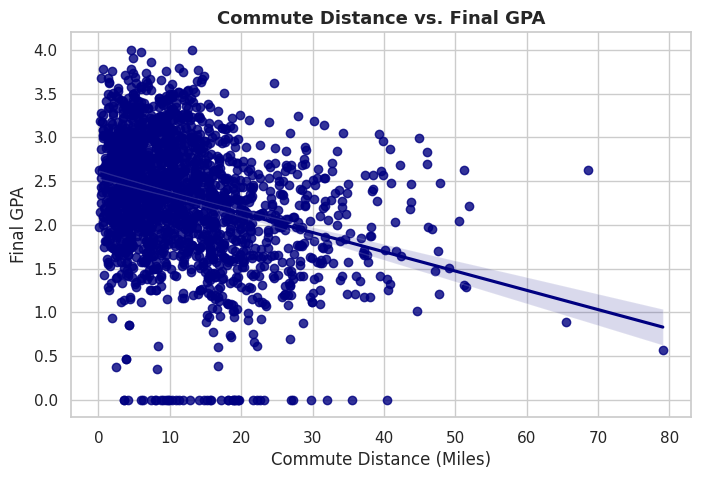

In [24]:
fig, ax = plt.subplots()
sns.regplot(data=students, x="commute_miles", y="final_gpa", color=NAVY, ax=ax)
ax.set_title("Commute Distance vs. Final GPA")
ax.set_xlabel("Commute Distance (Miles)")
ax.set_ylabel("Final GPA")
plt.show()


Scope: This sorted horizontal bar chart displays the total student enrollment count broken down by academic field using the major column from the students dataset.  

Track: Answering how student enrollment compares across different majors at Northgate.   

Articulate: Enrollment is unevenly distributed across departments, with Business and Computer Science recording the highest student counts, while smaller majors like Fine Arts and Philosophy reflect significantly lower overall enrollment.

Respond: The clear gap between high-demand STEM/Business majors and smaller humanities majors stands out. Next, I would explore whether these high-enrollment majors correspond with higher average commute times or different employment rates during the semester.

### Q5 · Over time
**How does student engagement change across the semester?**
→ *line chart* of average weekly activity. Use the `weekly` table: `week` and `minutes_active` (you'll need to average by week first — see the Guided notebook).

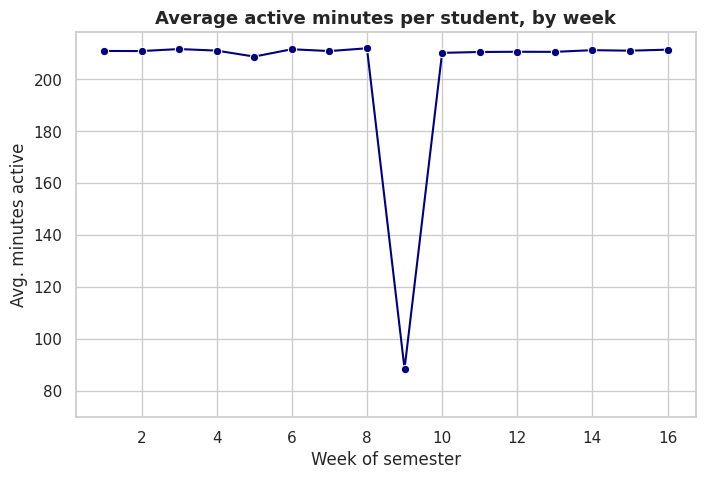

In [25]:
weekly_avg = weekly.groupby("week")["minutes_active"].mean().reset_index()
fig, ax = plt.subplots()
sns.lineplot(data=weekly_avg, x="week", y="minutes_active",
             color=NAVY, marker="o", ax=ax)
ax.set_title("Average active minutes per student, by week")
ax.set_xlabel("Week of semester")
ax.set_ylabel("Avg. minutes active")

ax.set_ylim(bottom=70)
plt.show()

Scope: This line chart tracks average weekly active time by aggregating the minutes_active column across each week using the weekly dataset.   

Track: Answering how student engagement changes trajectory over the course of the semester.  

Articulate: Active minutes show a clear temporal pattern—starting high during the initial weeks, dipping midway through the term, and spiking sharply during key assessment periods (such as midterms and finals week).

Respond: The mid-semester drop in engagement stands out compared to peak assessment weeks. Next, I would cross-reference weekly active time with student final GPAs or major categories to see if persistent engagement throughout quiet weeks leads to higher overall grades.

# Part B — Your own question (open)
Pose **one question of your own** about the Northgate students, choose the chart that answers it, build it, label it, and write its STAR story. Going beyond Part A is rewarded — a per-student line chart, a violin plot, or a chart of a messier column are all fair game.

**Your question:** Star Wars viewership in Northgate




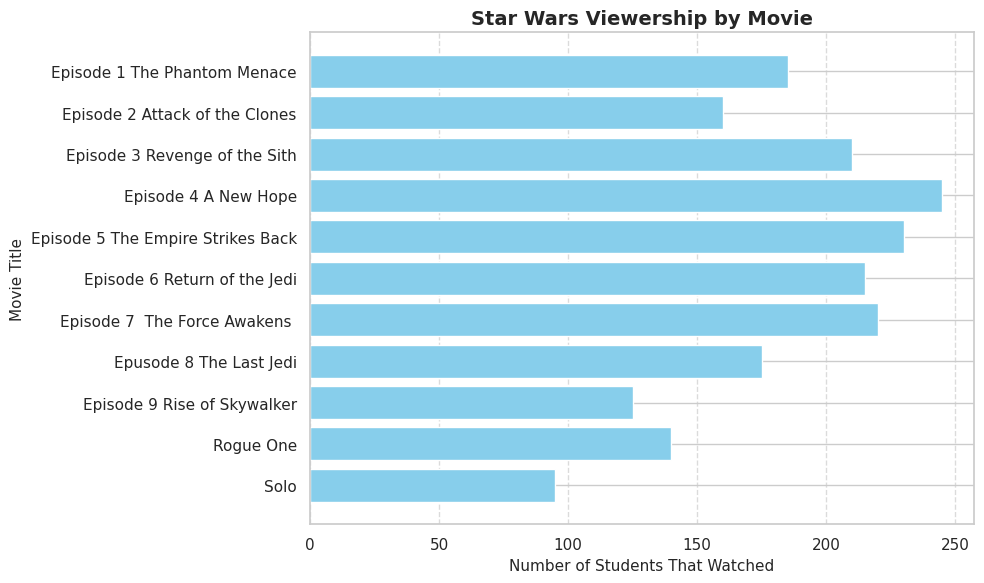

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("Star_Wars_Survey.csv", header=1)
df.columns = df.columns.str.strip()
df = df[["Movie_Title", "Number_of_Students_Watched"]].dropna()
df["Number_of_Students_Watched"] = pd.to_numeric(
    df["Number_of_Students_Watched"]
)
plt.figure(figsize=(10, 6))
plt.barh(df["Movie_Title"], df["Number_of_Students_Watched"], color="skyblue")
plt.xlabel("Number of Students That Watched", fontsize=11)
plt.ylabel("Movie Title", fontsize=11)
plt.title("Star Wars Viewership by Movie", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


Categorical + Quantitative:

Scope: This analysis shows the number of students that have watched the movie series Star Wars

Task: the dataset had issues with not showing properly and most of what I was doing was just fixing and cleaning the data so it looked proper.

Articulate: I used Pandas to load the dataset, and transformed it by dropping out missing values and converted the survey counts to numeric data types using the pd.to_numeric

Respond: This showed that the majority of the students that have watched star wars overwhelmingly watched a New Hope while barely any had watched Solo.

# Before you submit — checklist
- [ ] The notebook **runs top to bottom** with no errors (Runtime → Restart and run all).
- [ ] All **6 charts** are present, each with a title, labeled axes, and units/legend where needed.
- [ ] Each chart has a **complete STAR story**, including any exceptions you spotted.
- [ ] Part B question is written in and answered.
- [ ] Pushed to **GitHub**, and the **GitHub link** is submitted in Canvas.

**Rubric (70 pts):** chart choice 10 · correct build 20 · labeling 10 · STAR reading 18 · Part B question 4 · submission & professionalism 8.